In [1]:
# =========================
# CELL 1: CPU-only setup + Imports + Seed
# =========================

import os
import time
import random
import zipfile
from datetime import datetime

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image

from PIL import Image
import matplotlib.pyplot as plt

# REQUIRED BY ASSIGNMENT: CPU ONLY
device = torch.device("cpu")
print("Using device:", device)

# Reproducibility (helps grading)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print("Seed set to:", SEED)


Using device: cpu
Seed set to: 42


In [2]:
# =========================
# CELL 2: Mount Google Drive
# =========================

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
# =========================
# CELL 3: Extract CelebA ZIP from Drive (fast re-run safe)
# =========================

ZIP_PATH = "/content/drive/MyDrive/img_align_celeba.zip"  # <- my file
EXTRACT_DIR = "/content/data/celeba"
IMAGES_DIR = os.path.join(EXTRACT_DIR, "img_align_celeba")

print("ZIP_PATH:", ZIP_PATH)
print("EXTRACT_DIR:", EXTRACT_DIR)

os.makedirs(EXTRACT_DIR, exist_ok=True)

# Extract only if folder doesn't exist yet
if not os.path.exists(IMAGES_DIR):
    print("Unzipping... (one-time, may take a few minutes)")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
    print("Unzip complete.")
else:
    print("Already extracted. Skipping unzip.")

print("IMAGES_DIR:", IMAGES_DIR)
print("Example file count:", len(os.listdir(IMAGES_DIR)))


ZIP_PATH: /content/drive/MyDrive/img_align_celeba.zip
EXTRACT_DIR: /content/data/celeba
Unzipping... (one-time, may take a few minutes)
Unzip complete.
IMAGES_DIR: /content/data/celeba/img_align_celeba
Example file count: 202599


Total images: 202599
First 5 filenames: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg']


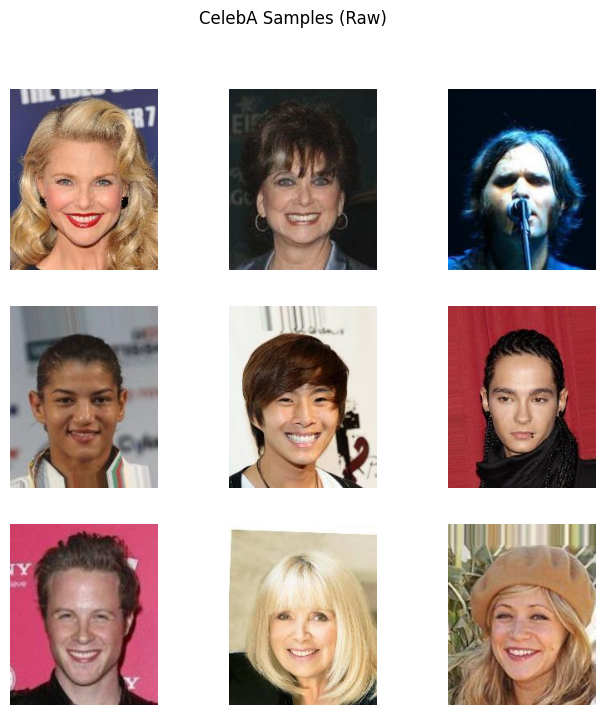

In [4]:
# =========================
# CELL 4: Inspect dataset (raw samples)
# =========================

files = sorted(os.listdir(IMAGES_DIR))
print("Total images:", len(files))
print("First 5 filenames:", files[:5])

sample = random.sample(files, 9)

plt.figure(figsize=(8, 8))
for i, f in enumerate(sample, 1):
    img = Image.open(os.path.join(IMAGES_DIR, f)).convert("RGB")
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.axis("off")
plt.suptitle("CelebA Samples (Raw)")
plt.show()


In [5]:
# =========================
# CELL 5: Transforms + Custom Dataset + DataLoader (FAST MODE)
# =========================

IMG_SIZE = 32        # smaller = MUCH faster on CPU (still meets requirement)
BATCH_SIZE = 64      # CPU-friendly
MAX_ITEMS = 8000     # <<< IMPORTANT: subset of CelebA to finish fast

# Why these transforms?
# - Resize/CenterCrop: makes a consistent square face crop
# - ToTensor: converts to torch tensor [0,1]
# - Normalize: maps to [-1, 1] which matches Generator's Tanh output
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

class CelebAFolderDataset(Dataset):
    """
    Loads CelebA images from a folder (flat directory of .jpg files).
    Reads images lazily (only when needed).
    """
    def __init__(self, images_dir, transform=None, max_items=None):
        self.images_dir = images_dir
        self.transform = transform
        self.files = sorted(os.listdir(images_dir))
        if max_items is not None:
            self.files = self.files[:max_items]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        path = os.path.join(self.images_dir, filename)
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

dataset = CelebAFolderDataset(IMAGES_DIR, transform=transform, max_items=MAX_ITEMS)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print("Using subset size:", len(dataset))
print("Batches per epoch:", len(dataloader))


Using subset size: 8000
Batches per epoch: 125


Batch shape: torch.Size([64, 3, 32, 32])
Min/Max (after normalize): -1.0 1.0


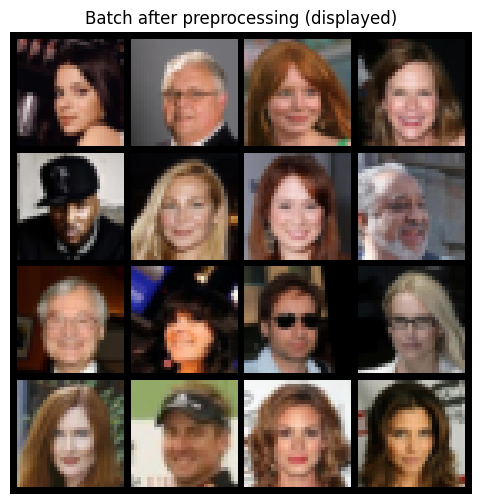

In [6]:
# =========================
# CELL 6: Verify preprocessing (normalized batch)
# =========================

batch = next(iter(dataloader))
print("Batch shape:", batch.shape)  # expected: [B, 3, IMG_SIZE, IMG_SIZE]
print("Min/Max (after normalize):", batch.min().item(), batch.max().item())

# Convert back from [-1,1] to [0,1] for display
grid = make_grid(batch[:16] * 0.5 + 0.5, nrow=4)
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Batch after preprocessing (displayed)")
plt.show()


In [7]:
# =========================
# CELL 7: Generator + Discriminator (DCGAN-style)
# =========================

Z_DIM = 100   # size of random noise vector
IMG_CH = 3    # RGB
FEATURES_G = 64
FEATURES_D = 64

class Generator(nn.Module):
    """
    Takes random noise (Z_DIM) and produces a fake image (3 x IMG_SIZE x IMG_SIZE).
    Uses ConvTranspose2d to "upsample" step-by-step.
    """
    def __init__(self, z_dim=Z_DIM, img_ch=IMG_CH, features=FEATURES_G):
        super().__init__()
        self.net = nn.Sequential(
            # Input: N x z_dim x 1 x 1

            nn.ConvTranspose2d(z_dim, features * 4, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.ReLU(True),
            # Now: N x (features*4) x 4 x 4

            nn.ConvTranspose2d(features * 4, features * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.ReLU(True),
            # Now: N x (features*2) x 8 x 8

            nn.ConvTranspose2d(features * 2, features, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features),
            nn.ReLU(True),
            # Now: N x features x 16 x 16

            nn.ConvTranspose2d(features, img_ch, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
            # Output: N x 3 x 32 x 32  (values in [-1,1])
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    """
    Takes an image and outputs a probability (real vs fake).
    Uses Conv2d to downsample and learn features.
    """
    def __init__(self, img_ch=IMG_CH, features=FEATURES_D):
        super().__init__()
        self.net = nn.Sequential(
            # Input: N x 3 x 32 x 32

            nn.Conv2d(img_ch, features, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # Now: N x features x 16 x 16

            nn.Conv2d(features, features * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # Now: N x (features*2) x 8 x 8

            nn.Conv2d(features * 2, features * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # Now: N x (features*4) x 4 x 4

            nn.Conv2d(features * 4, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()
            # Output: N x 1 x 1 x 1 (probability real)
        )

    def forward(self, x):
        return self.net(x).view(-1)

G = Generator().to(device)
D = Discriminator().to(device)

print("Generator and Discriminator created.")


Generator and Discriminator created.


In [8]:
# =========================
# CELL 8: Loss, Optimizers, Weight Initialization
# =========================

# Binary Cross Entropy = standard for basic GANs (matches rubric example)
criterion = nn.BCELoss()

lr = 2e-4
beta1 = 0.5  # DCGAN commonly uses beta1=0.5 for stability

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

def weights_init(m):
    """
    DCGAN weight initialization (helps stable training)
    """
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G.apply(weights_init)
D.apply(weights_init)

print("Initialized weights, loss, optimizers.")


Initialized weights, loss, optimizers.


In [9]:
# =========================
# CELL 9: Output folder + Fixed noise
# =========================

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = f"/content/gan_outputs_{run_id}"
os.makedirs(OUT_DIR, exist_ok=True)
print("Saving outputs to:", OUT_DIR)

fixed_noise = torch.randn(16, Z_DIM, 1, 1, device=device)


Saving outputs to: /content/gan_outputs_20260202_003339


In [10]:
# =========================
# CELL 10: Training Loop (CPU FAST MODE)
# =========================

EPOCHS = 2  #  set to 1 or 2 (fast). Still "several" if you do 2.

d_losses = []
g_losses = []

G.train()
D.train()

start_time = time.time()

try:
    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()

        for step, real_images in enumerate(dataloader, 1):
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            # Labels
            real_labels = torch.ones(batch_size, device=device)
            fake_labels = torch.zeros(batch_size, device=device)

            # -------------------------
            # (1) Train Discriminator
            # -------------------------
            D.zero_grad()

            # Real loss
            real_preds = D(real_images)
            d_loss_real = criterion(real_preds, real_labels)

            # Fake loss
            noise = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
            fake_images = G(noise)
            fake_preds = D(fake_images.detach())  # detach so G not updated here
            d_loss_fake = criterion(fake_preds, fake_labels)

            # Total D loss
            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            opt_D.step()

            # -------------------------
            # (2) Train Generator
            # -------------------------
            G.zero_grad()

            # Generator wants D(fake) to be "real" (label=1)
            fake_preds_for_G = D(fake_images)
            g_loss = criterion(fake_preds_for_G, real_labels)

            g_loss.backward()
            opt_G.step()

            # Logging
            d_losses.append(d_loss.item())
            g_losses.append(g_loss.item())

            # Print occasionally (keeps output readable)
            if step % 200 == 0:
                print(f"Epoch [{epoch}/{EPOCHS}] Step [{step}/{len(dataloader)}] "
                      f"D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

        # Save a sample image after each epoch (deliverable)
        G.eval()
        with torch.no_grad():
            samples = G(fixed_noise)
            samples = samples * 0.5 + 0.5  # [-1,1] -> [0,1]
            img_path = os.path.join(OUT_DIR, f"generated_epoch_{epoch}.png")
            save_image(samples, img_path, nrow=4)
            print("Saved sample image:", img_path)
        G.train()

        print(f"Epoch {epoch} finished in {time.time() - epoch_start:.2f} seconds")

except KeyboardInterrupt:
    print("Training stopped early (KeyboardInterrupt). That is OK for CPU feasibility.")
finally:
    # Always save loss log even if you stop early
    csv_path = os.path.join(OUT_DIR, "loss_log.csv")
    df_log = pd.DataFrame({"d_loss": d_losses, "g_loss": g_losses})
    df_log.to_csv(csv_path, index=False)
    print("Saved loss log:", csv_path)

print("Total run time (seconds):", time.time() - start_time)


Saved sample image: /content/gan_outputs_20260202_003339/generated_epoch_1.png
Epoch 1 finished in 79.16 seconds
Saved sample image: /content/gan_outputs_20260202_003339/generated_epoch_2.png
Epoch 2 finished in 69.88 seconds
Saved loss log: /content/gan_outputs_20260202_003339/loss_log.csv
Total run time (seconds): 149.06544470787048


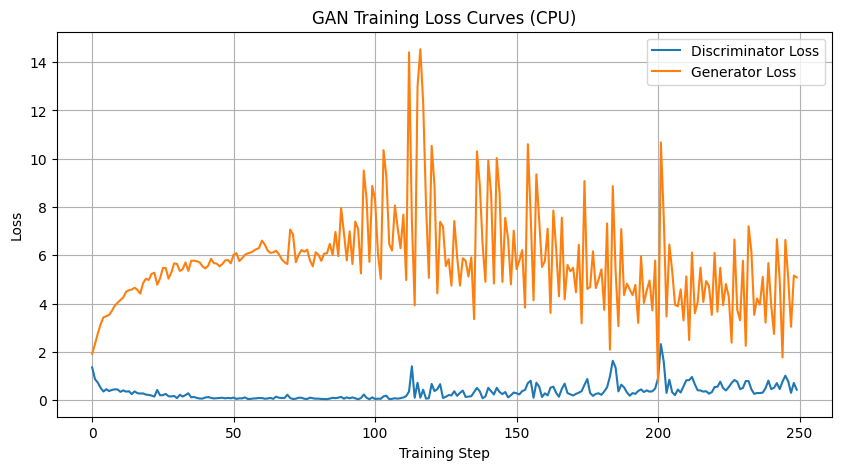

In [11]:
# =========================
# CELL 11: Plot loss curves (evaluation metric)
# =========================

df_log = pd.read_csv(os.path.join(OUT_DIR, "loss_log.csv"))

plt.figure(figsize=(10, 5))
plt.plot(df_log["d_loss"], label="Discriminator Loss")
plt.plot(df_log["g_loss"], label="Generator Loss")
plt.title("GAN Training Loss Curves (CPU)")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


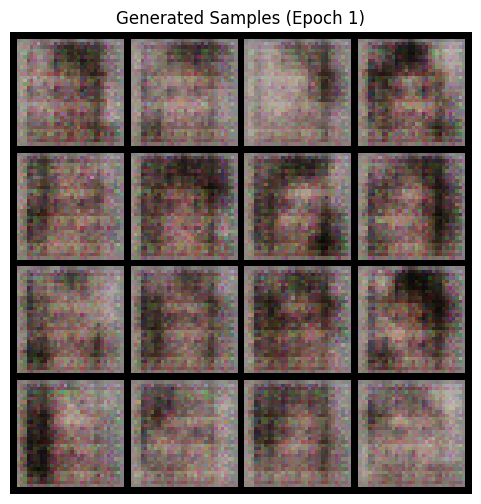

Image saved at: /content/gan_outputs_20260202_003339/generated_epoch_1.png


In [12]:
# =========================
# CELL 12: Display generated image (for screenshot)
# =========================

from PIL import Image
import matplotlib.pyplot as plt

# Change epoch number if you ran 1 epoch only
img_path = os.path.join(OUT_DIR, "generated_epoch_1.png")

img = Image.open(img_path)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Generated Samples (Epoch 1)")
plt.show()

print("Image saved at:", img_path)
